In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from lightgbm import LGBMClassifier
import warnings
from sklearn.model_selection import KFold, ParameterSampler, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import seaborn as sns
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

In [2]:
df_training = pd.read_parquet("data/best_training.parquet")
df_testing = pd.read_parquet("data/best_testing.parquet")
df_oot = pd.read_parquet("data/oot.parquet")

In [3]:
bundle = joblib.load('fraud_model_bundle.joblib')
model = bundle['model']
selected_features = bundle['selected_features']

In [4]:
X_training = df_training[selected_features]
y_training = df_training['Fraud']
X_testing = df_testing[selected_features]
y_testing = df_testing['Fraud']
X_oot = df_oot[selected_features]
y_oot = df_oot['Fraud']

In [5]:
pred_training = model.predict_proba(X_training)[:, 1]
pred_testing = model.predict_proba(X_testing)[:, 1]
pred_oot = model.predict_proba(X_oot)[:, 1]

In [6]:
def calculate_fdr_at_rate(y_true, y_pred_proba, detect_rate=0.03):
    n_top = int(round(len(y_true) * detect_rate))
    top_indices = np.argpartition(y_pred_proba, -n_top)[-n_top:]
    return y_true.iloc[top_indices].sum() / y_true.sum()

### Performance Visualization

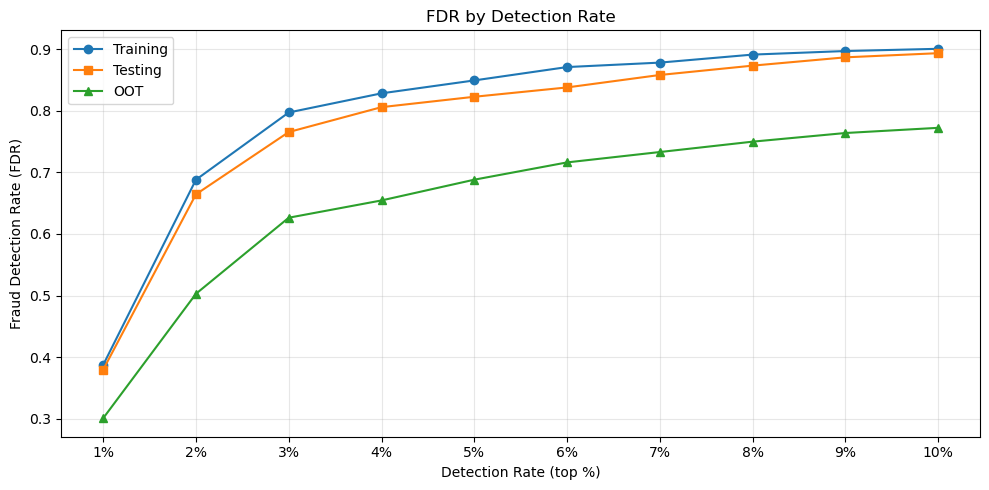

In [7]:
rates = np.arange(0.01, 0.11, 0.01)

fdr_training = [calculate_fdr_at_rate(y_training, pred_training, r) for r in rates]
fdr_testing  = [calculate_fdr_at_rate(y_testing,  pred_testing,  r) for r in rates]
fdr_oot      = [calculate_fdr_at_rate(y_oot,      pred_oot,      r) for r in rates]

fdr_df = pd.DataFrame({
    'Detection Rate': rates,
    'Training': fdr_training,
    'Testing': fdr_testing,
    'OOT': fdr_oot,
})

plt.figure(figsize=(10, 5))
plt.plot(rates, fdr_training, marker='o', label='Training')
plt.plot(rates, fdr_testing,  marker='s', label='Testing')
plt.plot(rates, fdr_oot,      marker='^', label='OOT')
plt.xlabel('Detection Rate (top %)')
plt.ylabel('Fraud Detection Rate (FDR)')
plt.title('FDR by Detection Rate')
plt.xticks(rates, [f'{r:.0%}' for r in rates])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Performance Reporting
The table below is generated for reporting purposes. Please check *Real Time Fraud Detection Model Report.pdf* for details.

In [8]:
def build_fdr_table(y_true, y_pred_proba, cost_fraud=400, cost_fp=20):
    """Build a percentile-level FDR table (0-100%) for a scored dataset."""
    n = len(y_true)
    total_fraud = y_true.sum()
    total_good = n - total_fraud

    # Sort by predicted probability descending
    order = np.argsort(-y_pred_proba)
    y_sorted = y_true.values[order]

    rows = []
    for pct in range(0, 101):
        k = int(round(n * pct / 100))
        cum_fraud = y_sorted[:k].sum()
        cum_good = k - cum_fraud

        fdr = 100 * cum_fraud / total_fraud if total_fraud > 0 else 0
        cum_good_pct = 100 * cum_good / total_good if total_good > 0 else 0
        ks = fdr - cum_good_pct
        fpr = cum_good / cum_fraud if cum_fraud > 0 else np.nan

        fraud_savings = cum_fraud * cost_fraud
        fp_loss = cum_good * cost_fp
        net_savings = fraud_savings - fp_loss

        rows.append({
            'Percentile': pct,
            'Reviewed': k,
            'Cum Fraud': int(cum_fraud),
            'Cum Good': int(cum_good),
            'FDR (%)': round(fdr, 2),
            'Cum Good (%)': round(cum_good_pct, 2),
            'KS': round(ks, 2),
            'FP Ratio': round(fpr, 2) if not np.isnan(fpr) else np.nan,
            'Fraud Savings ($)': fraud_savings,
            'FP Loss ($)': fp_loss,
            'Net Savings ($)': net_savings,
        })

    return pd.DataFrame(rows)

In [9]:
fdr_table_training = build_fdr_table(y_training, pred_training)
fdr_table_testing  = build_fdr_table(y_testing,  pred_testing)
fdr_table_oot      = build_fdr_table(y_oot,      pred_oot)

fdr_table_oot.iloc[1:6]

,Percentile,Reviewed,Cum Fraud,Cum Good,FDR (%),Cum Good (%),KS,FP Ratio,Fraud Savings ($),FP Loss ($),Net Savings ($)
1,1,126,107,19,30.06,0.15,29.90,0.18,42800,380,42420
2,2,253,179,74,50.28,0.60,49.68,0.41,71600,1480,70120
3,3,379,223,156,62.64,1.27,61.37,0.70,89200,3120,86080
4,4,505,233,272,65.45,2.21,63.23,1.17,93200,5440,87760
5,5,632,245,387,68.82,3.15,65.67,1.58,98000,7740,90260


In [10]:
fdr_table_training.to_csv("data/fdr_table_training.csv", index=False)
fdr_table_testing.to_csv("data/fdr_table_testing.csv", index=False)
fdr_table_oot.to_csv("data/fdr_table_oot.csv", index=False)

Below is the visualization of the model performance.

In [11]:
METRIC_COLS = [
    "Percentile",
    "TP",
    "FP",
    "FN",
    "TN",
    "Accuracy",
    "Misclass",
    "FP Rate",
    "FP Ratio",
    "TPR",
    "TNR",
    "Precision",
    "F1",
]


def build_metrics(fdr_table, total_fraud, total_good):
    """Derive classification metrics from an FDR table at each percentile."""
    m = fdr_table[["Percentile", "Cum Fraud", "Cum Good"]].copy()
    n = total_fraud + total_good
    m["TP"] = m["Cum Fraud"]
    m["FP"] = m["Cum Good"]
    m["FN"] = total_fraud - m["TP"]
    m["TN"] = total_good - m["FP"]
    m["Accuracy"] = (m["TP"] + m["TN"]) / n
    m["Misclass"] = (m["FP"] + m["FN"]) / n
    m["FP Rate"] = m["FP"] / (m["FP"] + m["TN"])
    m["FP Ratio"] = m["FP"] / m["TP"].replace(0, np.nan)
    m["TPR"] = m["TP"] / (m["TP"] + m["FN"])
    m["TNR"] = m["TN"] / (m["TN"] + m["FP"])
    m["Precision"] = m["TP"] / (m["TP"] + m["FP"]).replace(0, np.nan)
    m["F1"] = (
        2 * m["Precision"] * m["TPR"] / (m["Precision"] + m["TPR"]).replace(0, np.nan)
    )
    return m[METRIC_COLS]


metrics_training = build_metrics(
    fdr_table_training, y_training.sum(), (y_training == 0).sum()
)
metrics_testing = build_metrics(
    fdr_table_testing, y_testing.sum(), (y_testing == 0).sum()
)
metrics_oot = build_metrics(fdr_table_oot, y_oot.sum(), (y_oot == 0).sum())

metrics_oot.to_csv("data/metrics_oot.csv", index=False)
metrics_oot.iloc[1:6]

,Percentile,TP,FP,FN,TN,Accuracy,Misclass,FP Rate,FP Ratio,TPR,TNR,Precision,F1
1,1,107,19,249,12262,0.978792,0.021208,0.001547,0.177570,0.300562,0.998453,0.849206,0.443983
2,2,179,74,177,12207,0.980138,0.019862,0.006026,0.413408,0.502809,0.993974,0.707510,0.587849
3,3,223,156,133,12125,0.977131,0.022869,0.012703,0.699552,0.626404,0.987297,0.588391,0.606803
4,4,233,272,123,12009,0.968743,0.031257,0.022148,1.167382,0.654494,0.977852,0.461386,0.541231
5,5,245,387,111,11894,0.960592,0.039408,0.031512,1.579592,0.688202,0.968488,0.387658,0.495951


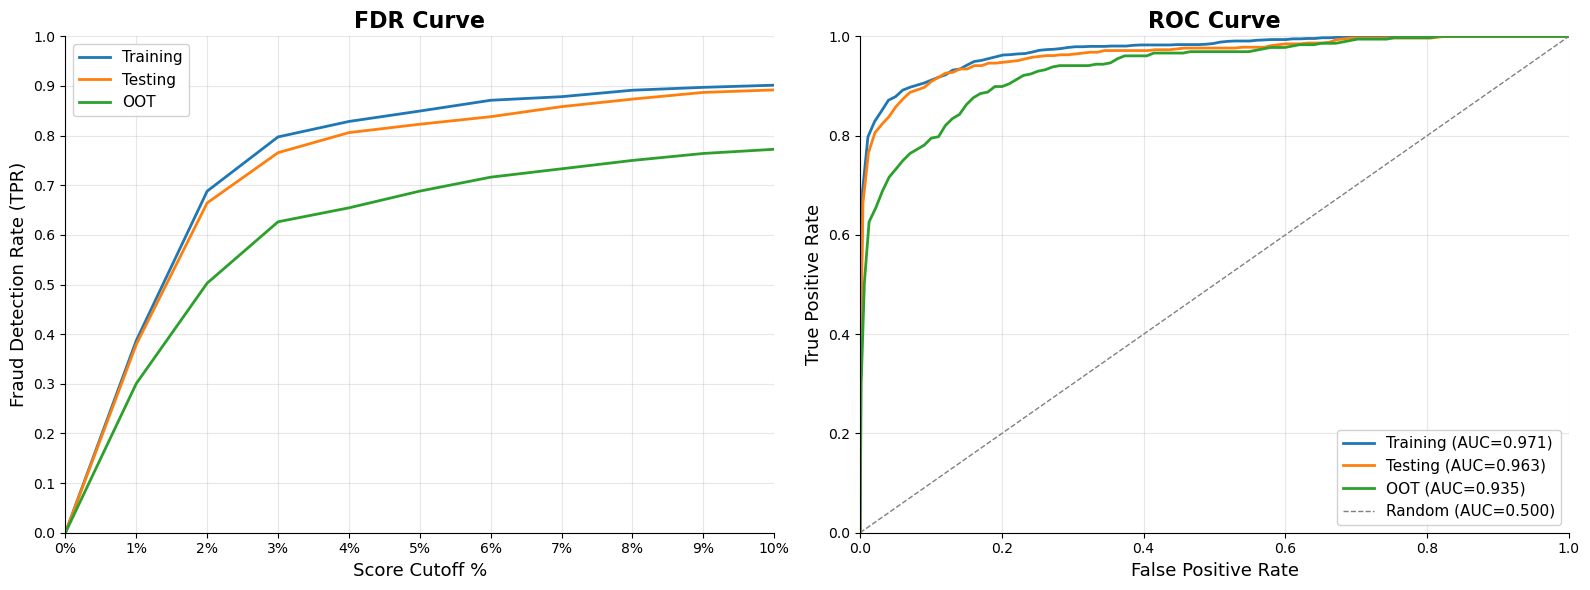

AUC — Training: 0.9712 | Testing: 0.9634 | OOT: 0.9352


In [ ]:
auc_training = roc_auc_score(y_training, pred_training)
auc_testing  = roc_auc_score(y_testing,  pred_testing)
auc_oot      = roc_auc_score(y_oot,      pred_oot)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- FDR Curve (left) ---
for label, m, color, marker in [
    ('Training', metrics_training, '#1f77b4', 'o'),
    ('Testing',  metrics_testing,  '#ff7f0e', 's'),
    ('OOT',      metrics_oot,      '#2ca02c', '^'),
]:
    ax1.plot(m['Percentile'], m['TPR'], color=color, linewidth=2, label=label)

ax1.set_xlim(0, 10)
ax1.set_ylim(0, 1)
ax1.set_xticks(range(0, 11))
ax1.set_yticks(np.arange(0, 1.1, 0.1))
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax1.set_xlabel('Score Cutoff %', fontsize=13)
ax1.set_ylabel('Fraud Detection Rate (TPR)', fontsize=13)
ax1.set_title('FDR Curve', fontsize=16, fontweight='bold')
ax1.legend(fontsize=11, framealpha=0.9)
ax1.grid(alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- ROC Curve (right) ---
for label, m, color, auc in [
    ('Training', metrics_training, '#1f77b4', auc_training),
    ('Testing',  metrics_testing,  '#ff7f0e', auc_testing),
    ('OOT',      metrics_oot,      '#2ca02c', auc_oot),
]:
    ax2.plot(m['FP Rate'], m['TPR'], color=color, linewidth=2, label=f'{label} (AUC={auc:.3f})')

ax2.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1, label='Random (AUC=0.500)')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.set_xlabel('False Positive Rate', fontsize=13)
ax2.set_ylabel('True Positive Rate', fontsize=13)
ax2.set_title('ROC Curve', fontsize=16, fontweight='bold')
ax2.legend(fontsize=11, loc='lower right', framealpha=0.9)
ax2.grid(alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fdr_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'AUC — Training: {auc_training:.4f} | Testing: {auc_testing:.4f} | OOT: {auc_oot:.4f}')

#### Financial Performance Reporting

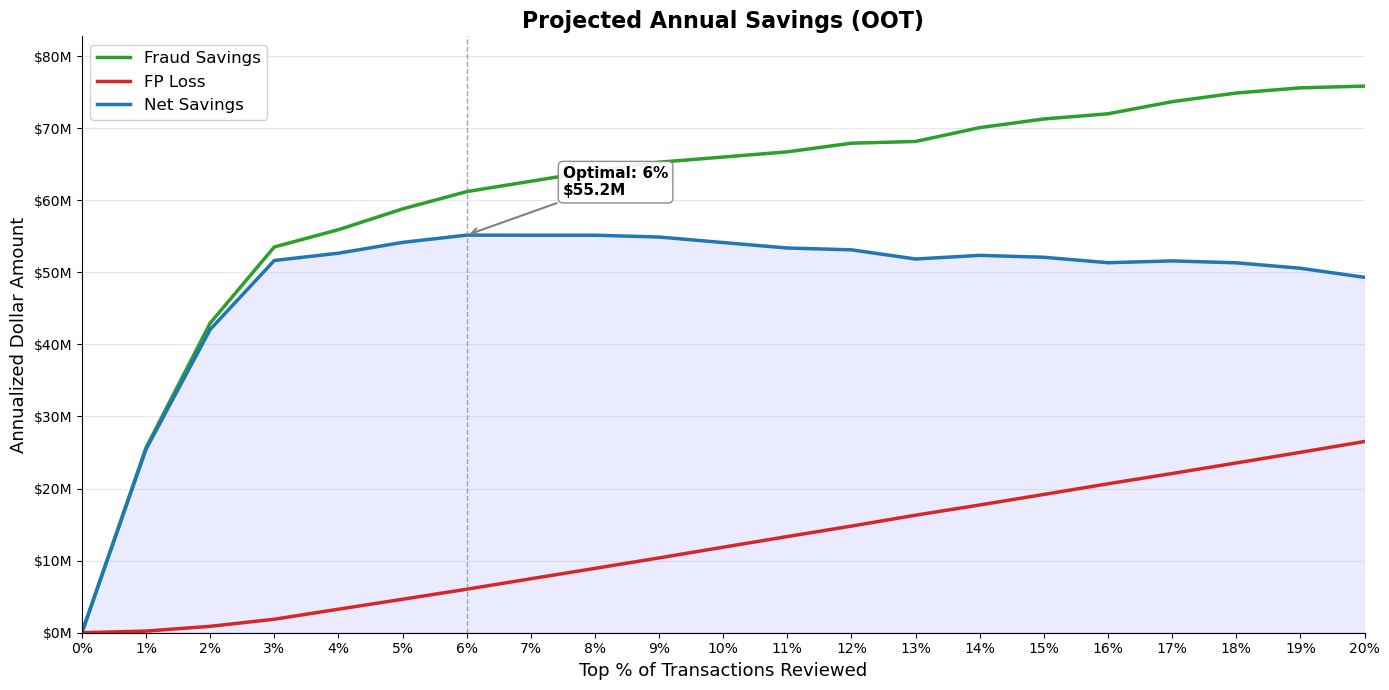

In [13]:
# OOT covers 2 of 12 months; 100k sample out of ~10M annual transactions; scale to annualized savings in millions of dollars
SCALE_FACTOR = (12 / 2) * (10_000_000 / 100_000) / 1_000_000


def build_financials(fdr_table, scale=SCALE_FACTOR):
    return pd.DataFrame(
        {
            "Percentile": fdr_table["Percentile"],
            "Fraud Savings ($)": fdr_table["Fraud Savings ($)"] * scale,
            "FP Loss ($)": fdr_table["FP Loss ($)"] * scale,
            "Net Savings ($)": fdr_table["Net Savings ($)"] * scale,
        }
    )


fin_training = build_financials(fdr_table_training)
fin_testing = build_financials(fdr_table_testing)
fin_oot = build_financials(fdr_table_oot)

# Plot OOT financials
max_savings = fin_oot["Net Savings ($)"].max()
optimal_pct = fin_oot.loc[fin_oot["Net Savings ($)"].idxmax(), "Percentile"]

fig, ax = plt.subplots(figsize=(14, 7))

ax.fill_between(
    fin_oot["Percentile"], fin_oot["Net Savings ($)"], alpha=0.08, color="blue"
)
ax.plot(
    fin_oot["Percentile"],
    fin_oot["Fraud Savings ($)"],
    color="#2ca02c",
    linewidth=2.5,
    label="Fraud Savings",
)
ax.plot(
    fin_oot["Percentile"],
    fin_oot["FP Loss ($)"],
    color="#d62728",
    linewidth=2.5,
    label="FP Loss",
)
ax.plot(
    fin_oot["Percentile"],
    fin_oot["Net Savings ($)"],
    color="#1f77b4",
    linewidth=2.5,
    label="Net Savings",
)

ax.axvline(x=optimal_pct, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.annotate(
    f"Optimal: {optimal_pct}%\n${max_savings:,.1f}M",
    xy=(optimal_pct, max_savings),
    xytext=(optimal_pct + 1.5, max_savings * 1.1),
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="grey", lw=1.5),
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", alpha=0.9),
)

ax.set_xlim(0, 20)
ax.set_ylim(0, max_savings * 1.5)
ax.set_xticks(range(0, 21))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}%"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"${y:,.0f}M"))
ax.set_xlabel("Top % of Transactions Reviewed", fontsize=13)
ax.set_ylabel("Annualized Dollar Amount", fontsize=13)
ax.set_title("Projected Annual Savings (OOT)", fontsize=16, fontweight="bold")
ax.legend(fontsize=12, loc="upper left", framealpha=0.9)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("savings.png", format="png", dpi=150, bbox_inches="tight")
plt.show()